# Goal

Decomposite the orbital decay curve into trend and seasonal components usint Lomb-Scargle and STL.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from utils.data_loader import find_repo_root
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from utils.data_loader import load_parquet
from utils.plot_loader import plot_lombscargle_periodogram

# Data

In [2]:
# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


Lets have a look at the raw data:

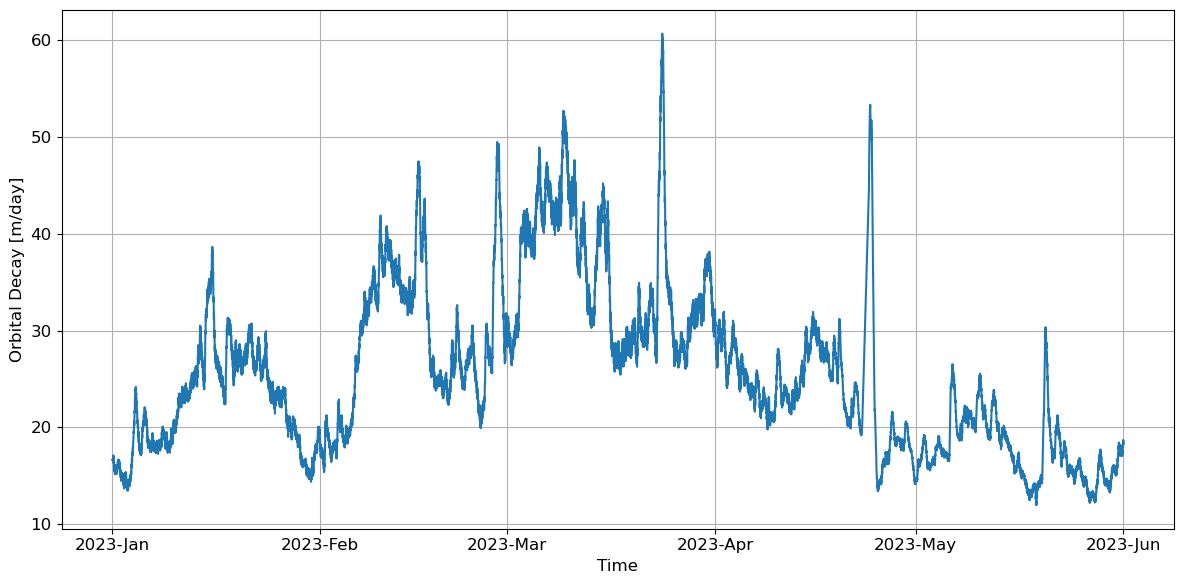

In [3]:
from utils.plot_loader import plot_orbital_decay

# =========================== Input ===================================
start_date = '2023-01-01 00:00:00'
end_date = '2023-06-01 00:00:00'
# start_date = pd.to_datetime(GFOC_data['time'].iloc[0])
# end_date = pd.to_datetime(GFOC_data['time'].iloc[-1]) #removed gap by ignoring the last 4321 values (for csv)

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

Flags = False

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=Flags)

# STL filter

In [4]:
def stl_decomposition(y, day):
    period = int(day * 24 * 60 * 3) # 1: 22.77 days, 2: 
    print(f"using a period of {period/(180*24)} days")
    seasonal = 100 * period + ((100*period % 2) == 0)  # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period + 1))
    trend_jump = int(0.15 * 1.5 * (period + 1))

    mod = STL(
        y['orbital_decay'],
        period=period,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
        seasonal_deg=0,
        robust=True
    )
    %timeit mod.fit()
    res = mod.fit()

    # plot
    plt.rc("figure", figsize=(12, 10))
    plt.rc("font", size=13)
    fig = res.plot()
    return res

## 1. Remove trend using STL decomposition

using a period of 3.9298611111111112 days
47 s ± 881 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


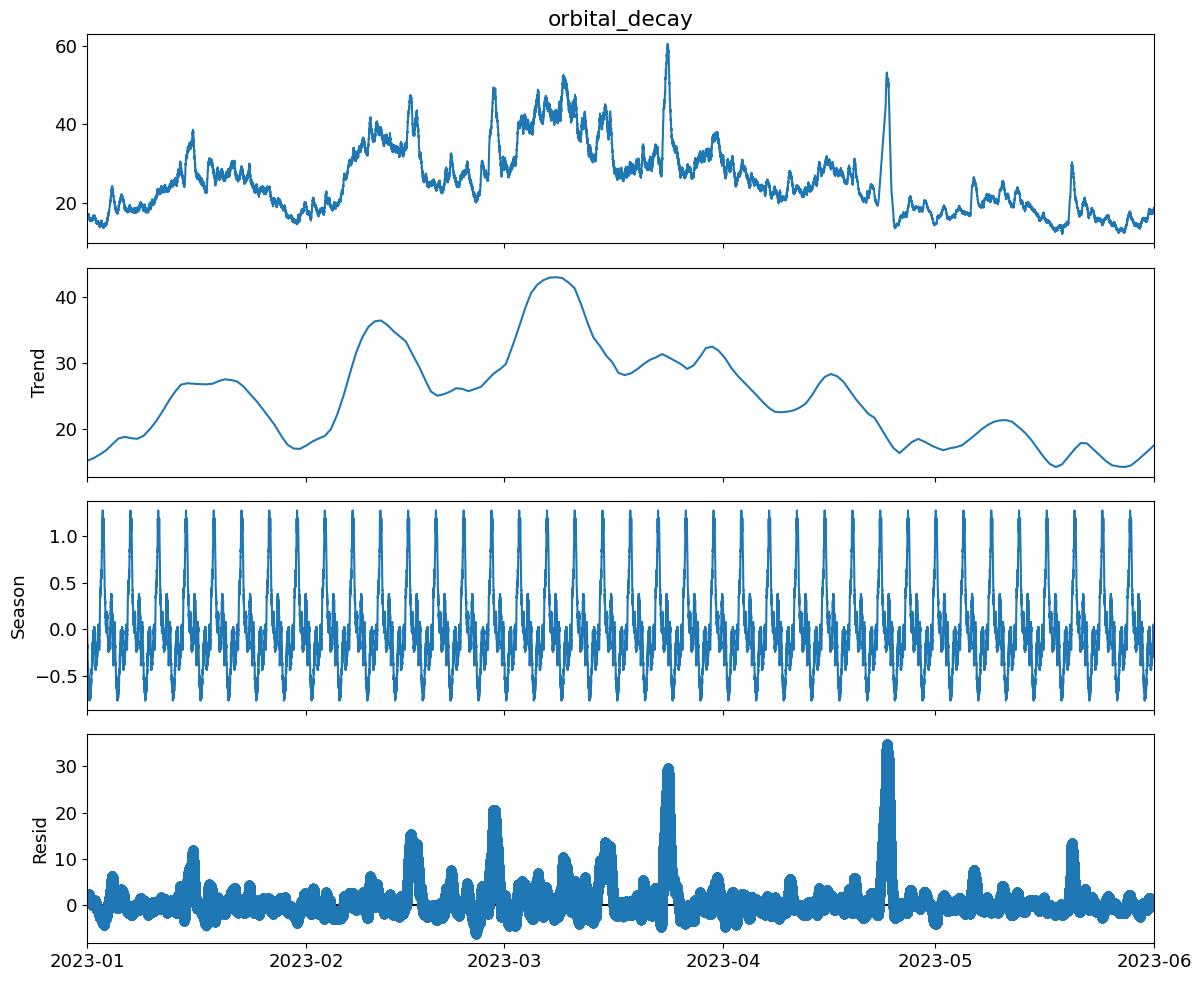

In [5]:
# Use time as index for y
GFOC_subset = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)].copy()
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

# all Periods found by Lomb-Scargle periodogram
days_S1 = [23.02, 28.68, 47.50, 14.38, 3.93, 5.19, 8.34, 12.06, 6.01, 7.61]

res_1 = stl_decomposition(y, 3.93)

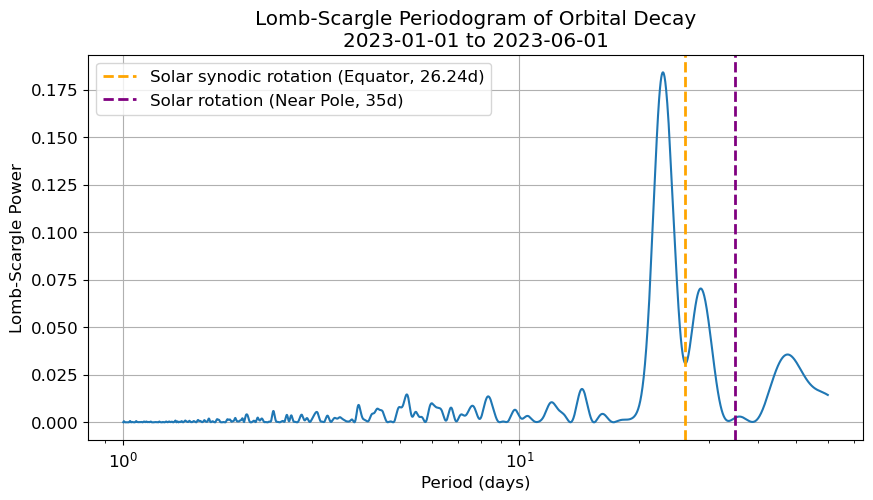

1. Period: 23.0186 +1.6849 -1.4454 days
2. Period: 28.6712 +2.0997 -1.9932 days
3. Period: 47.5006 +8.1687 -4.6442 days
4. Period: 14.3800 +0.4827 -0.4472 days
5. Period: 5.1959 +0.0988 -0.2547 days
6. Period: 8.3384 +0.2633 -0.2307 days
7. Period: 12.0563 +0.7012 -0.4167 days
8. Period: 6.0061 +0.3915 -0.1199 days
9. Period: 3.9264 +0.0581 -0.0460 days
10. Period: 7.6073 +0.1978 -0.2413 days


In [8]:
# GFOC_subset['trend_1'] = res_1.trend.values
GFOC_subset['seasonal_1'] = res_1.seasonal.values
# GFOC_subset['residual'] = res_1.resid.values + res_1.trend.values

GFOC_subset['orbital_decay'] = res_1.resid.values + res_1.trend.values
# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    show=False
)

## 2. Remove Periodic Signal and non-linear Trend

using a period of 23.01990740740741 days
54.5 s ± 6.06 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


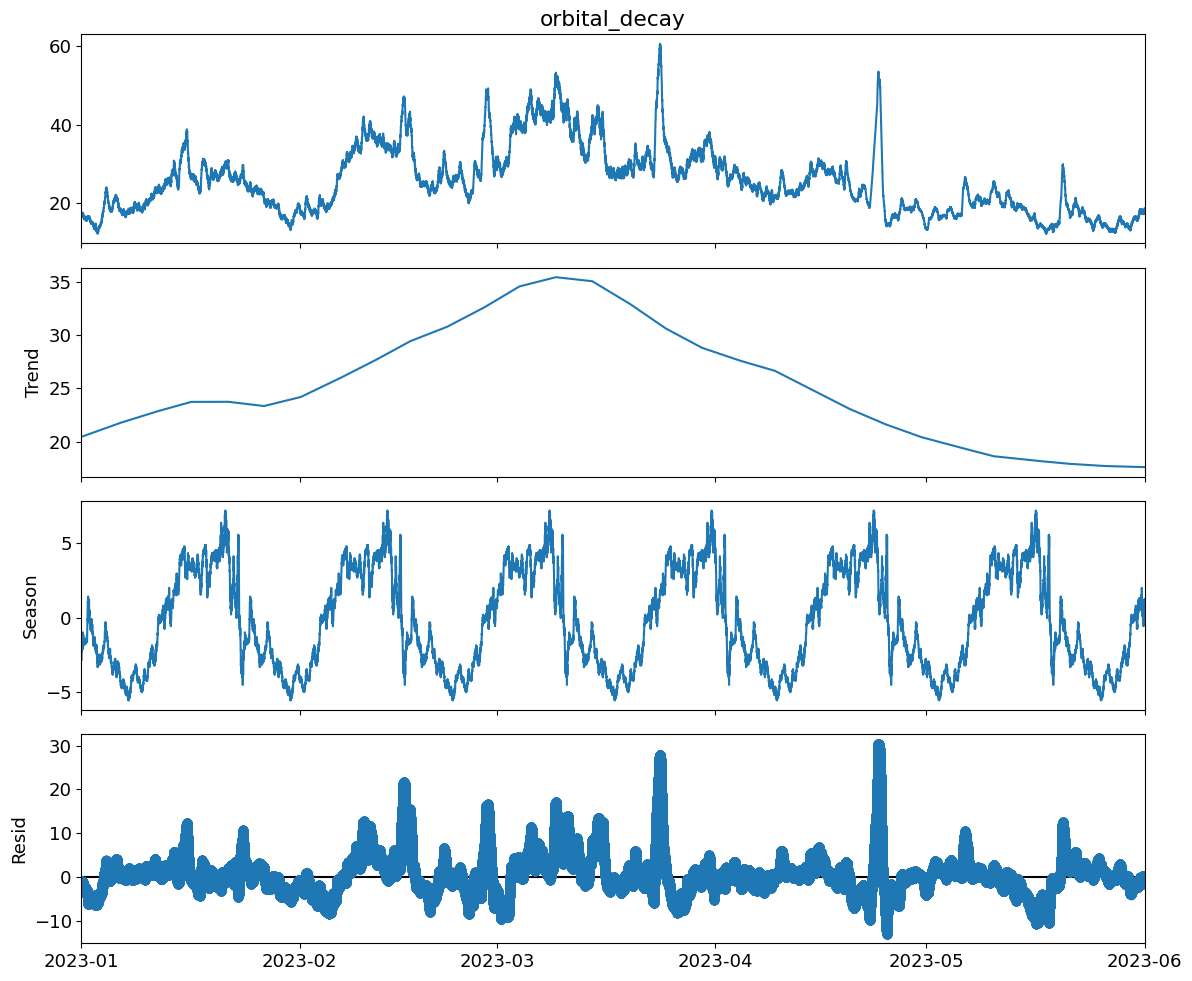

In [9]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_2 = stl_decomposition(y, 23.02)

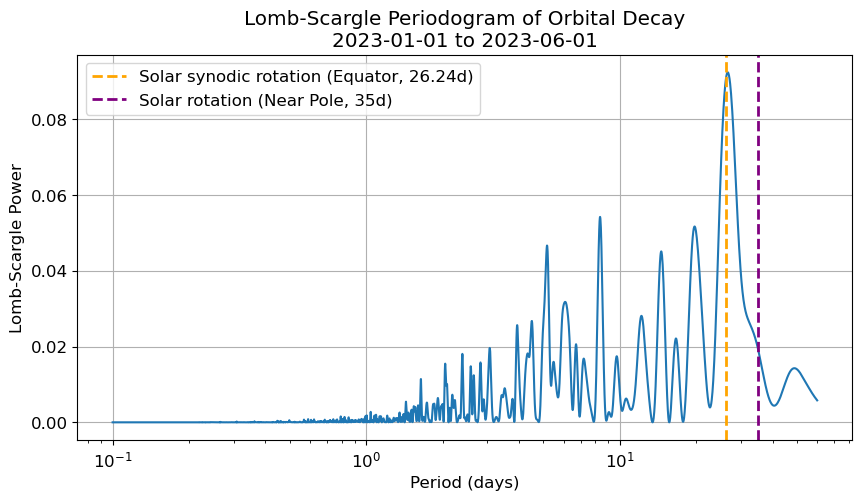

1. Period: 26.6439 +2.8939 -2.2098 days
2. Period: 8.3545 +0.2183 -0.2039 days
3. Period: 19.7199 +1.4928 -1.0651 days
4. Period: 5.1660 +0.1086 -0.1998 days
5. Period: 14.5602 +0.5374 -0.5302 days
6. Period: 6.0893 +0.2964 -0.2621 days
7. Period: 12.1717 +0.5787 -0.5237 days
8. Period: 4.4979 +0.0795 -0.2571 days
9. Period: 3.9374 +0.0715 -0.0519 days
10. Period: 16.6404 +0.5554 -0.5351 days


In [10]:
GFOC_subset['trend_1'] = res_2.trend.values
GFOC_subset['seasonal_2'] = res_2.seasonal.values
GFOC_subset['residual'] = res_2.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=60,  # days
    show=False
)

## 3. Remove secondary seasonal components

using a period of 26.639814814814816 days
56.6 s ± 3.65 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


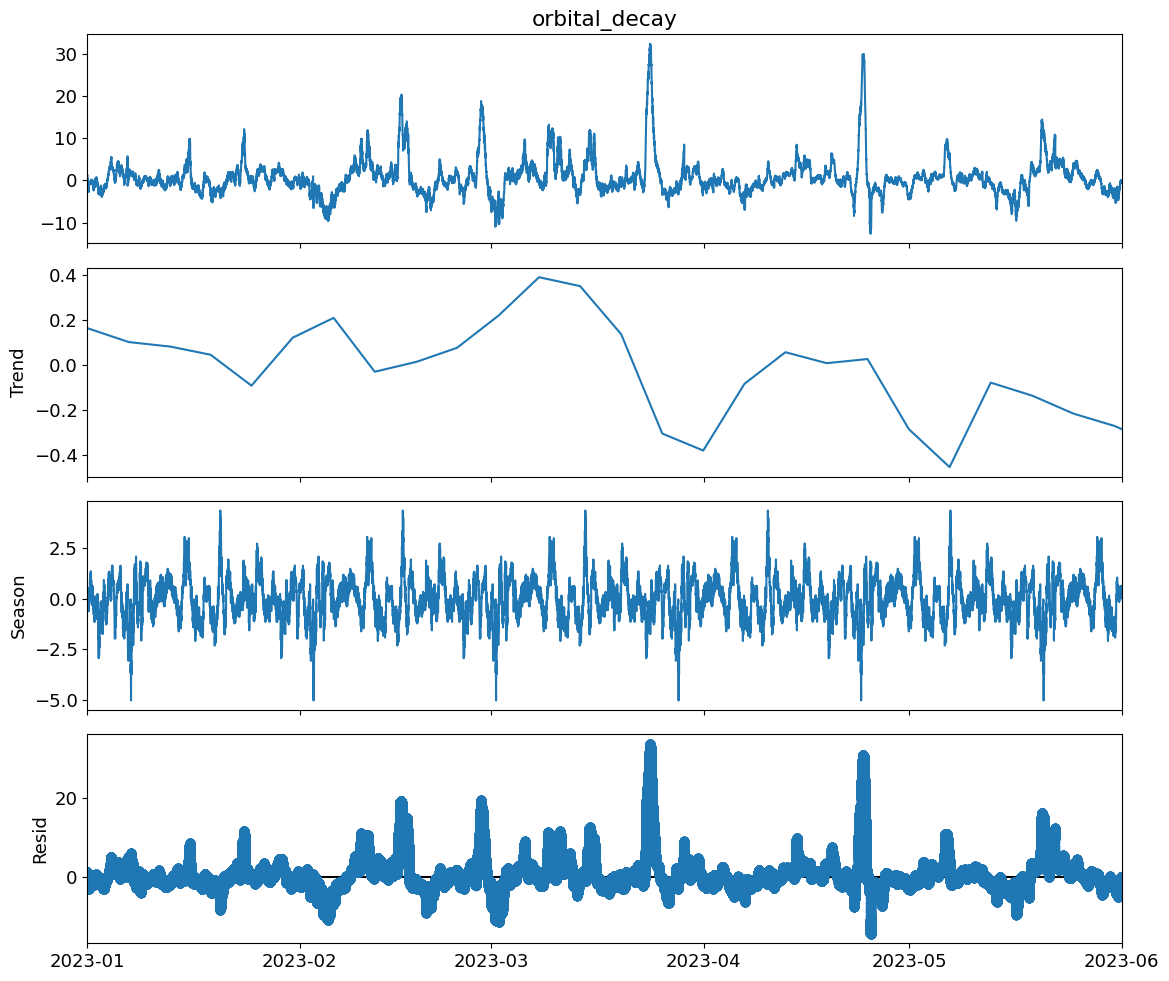

In [14]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_3 = stl_decomposition(y, 26.64)

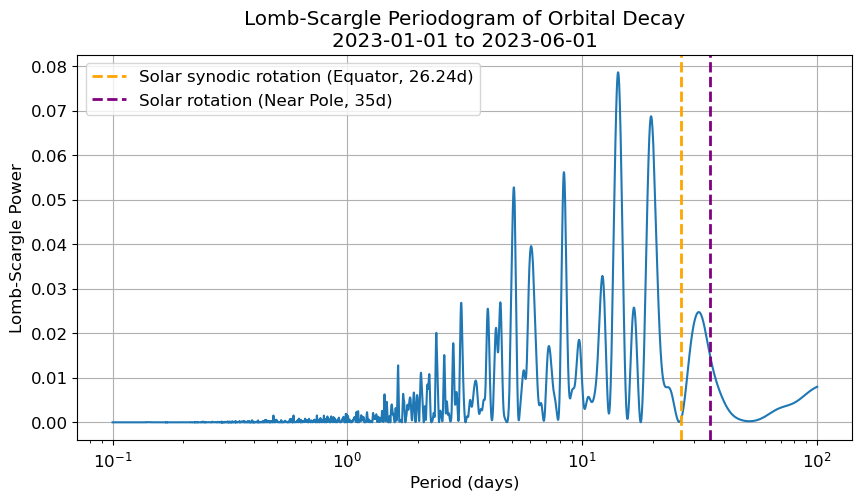

1. Period: 14.1965 +0.6564 -0.6347 days
2. Period: 19.6235 +1.2339 -0.9865 days
3. Period: 8.3479 +0.2376 -0.2170 days
4. Period: 5.1094 +0.1212 -0.1371 days
5. Period: 6.0552 +0.2720 -0.2087 days
6. Period: 12.1760 +0.4239 -0.5108 days
7. Period: 4.4765 +0.0786 -0.2495 days
8. Period: 3.0498 +0.0484 -0.0403 days
9. Period: 16.5975 +0.5609 -0.5841 days
10. Period: 3.9595 +0.0711 -0.0677 days


In [15]:
GFOC_subset['trend_2'] = res_3.trend.values
GFOC_subset['seasonal_3'] = res_3.seasonal.values
GFOC_subset['residual'] = res_3.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=100,  # days
    show=False
)

# Plot Results

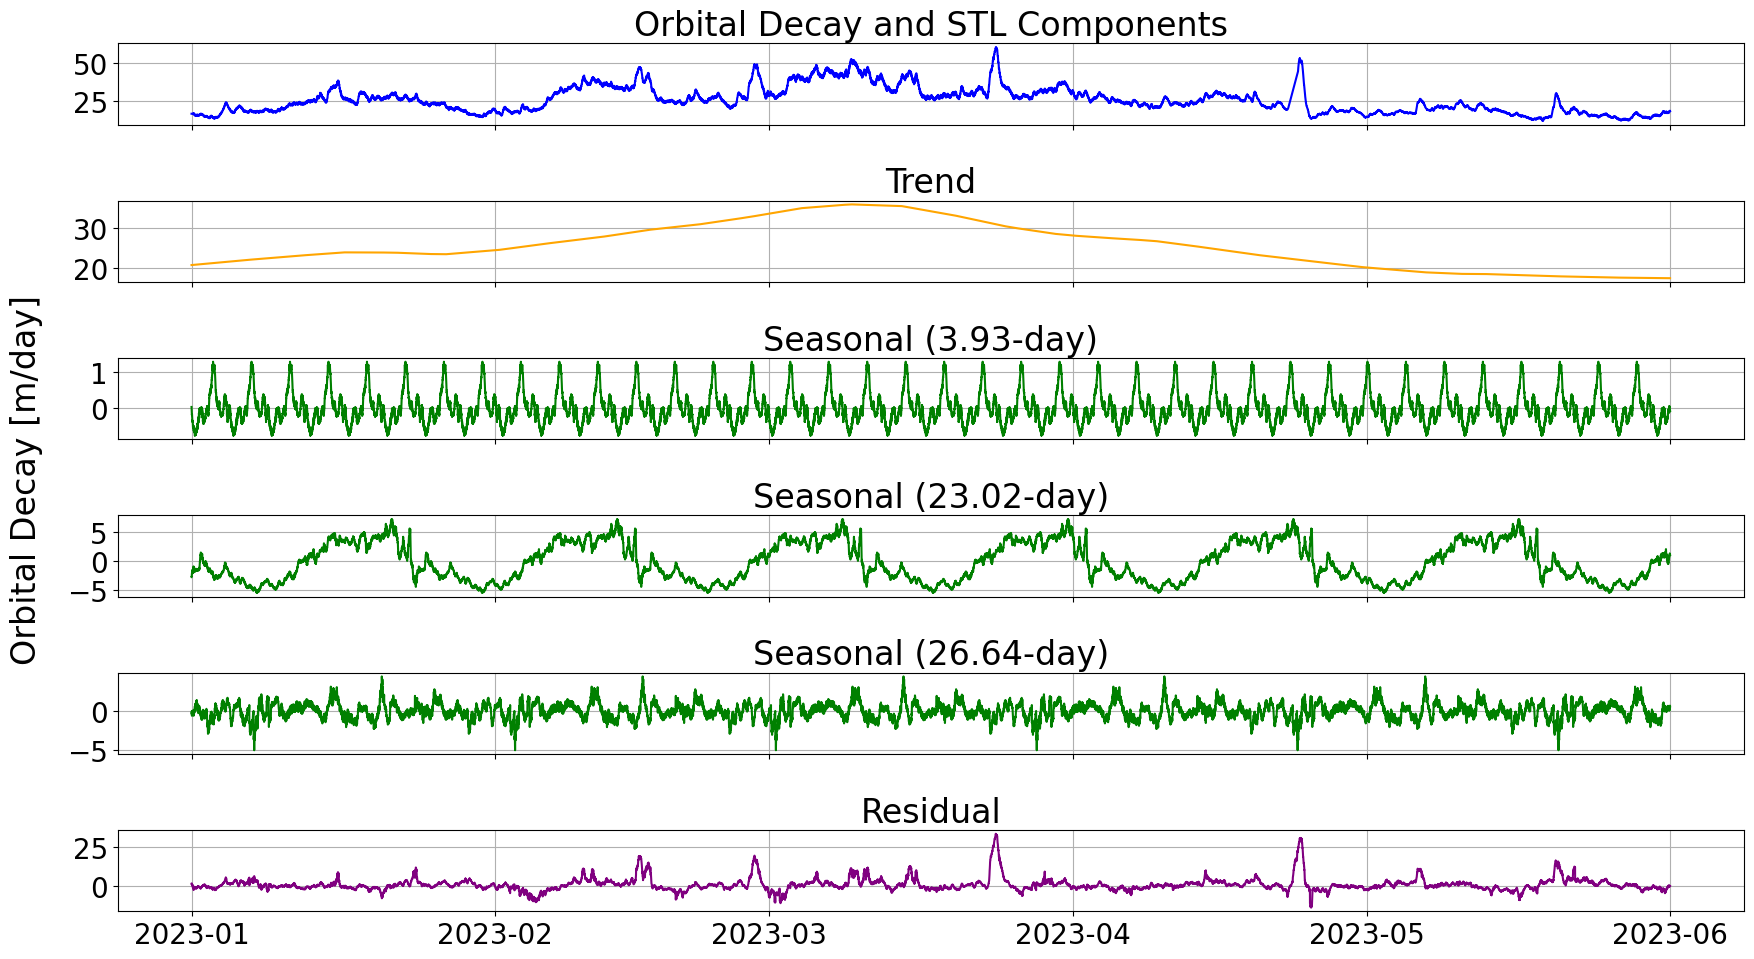

In [23]:
# set font & label size
plt.rcParams.update({'font.size': 20})

GFOC_subset['original_decay'] = GFOC_data['orbital_decay'].where(GFOC_data['time'].isin(GFOC_subset['time']))
# plot components
fig, axs = plt.subplots(6, 1, figsize=(18, 10), sharex=True)
axs[0].plot(GFOC_subset['time'], GFOC_subset['original_decay'], color='blue')
axs[0].set_title('Orbital Decay and STL Components')

axs[1].plot(GFOC_subset['time'], GFOC_subset['trend_1'] + GFOC_subset['trend_2'], color='orange')
axs[1].set_title('Trend')

axs[2].plot(GFOC_subset['time'], GFOC_subset['seasonal_1'], color='green')
axs[2].set_title('Seasonal (3.93-day)')

axs[3].plot(GFOC_subset['time'], GFOC_subset['seasonal_2'], color='green')
axs[3].set_title('Seasonal (23.02-day)')

axs[4].plot(GFOC_subset['time'], GFOC_subset['seasonal_3'], color='green')
axs[4].set_title('Seasonal (26.64-day)')

axs[5].plot(GFOC_subset['time'], GFOC_subset['residual'], color='purple')
axs[5].set_title('Residual')

for ax in axs:
    # ax.legend()
    ax.grid()
# plt.xlabel('time')
fig.supylabel('Orbital Decay [m/day]')

plt.tight_layout()
plt.show()

In [27]:
print("Trend:")
trend = GFOC_subset['trend_1'] + GFOC_subset['trend_2']
print(f"Start value: {trend.iloc[0]:.2f}, End value: {trend.iloc[-1]:.2f}")
max_idx = trend.idxmax()
max_time = max_idx if isinstance(max_idx, pd.Timestamp) else GFOC_subset.loc[max_idx, 'time']
print(f"Max value: {trend.max():.2f} at time: {max_time}")

Trend:
Start value: 20.62, End value: 17.34
Max value: 35.79 at time: 2023-03-09 07:58:00
